# Inspect Audio / Visual / DOA Dataset

这个 notebook 用来检查 `data/bag_name/{audio,image,depth,odom,doa}` 结构的数据。

- 上方先画出一个 sequence 里的整体轨迹和声源位置
- slider 可以逐帧查看样本
- 每帧显示当前位姿、DOA 方向、RGB、depth、audio waveform、audio spectrogram、DOA Gaussian 和 distance Gaussian

In [37]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
import ipywidgets as widgets

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'dataloader').exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from dataloader import AudioVisualDoaDataset

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

## Config

In [62]:
DATA_ROOT = REPO_ROOT / 'data'/'test'
SEQ_INDEX = 1



AUDIO_CHANNELS = '1234'
IMAGE_SIZE = (224, 224)
DOA_NUM_BINS = 360
DISTANCE_NUM_BINS = 120
DISTANCE_MIN = 0.0
DISTANCE_MAX = 6.0

print('DATA_ROOT =', DATA_ROOT)

DATA_ROOT = /home/kemove/yyz/audio-nav/respeaker_ros/data/test


## Helpers

In [63]:
def numeric_stem(path):
    try:
        return int(Path(path).stem)
    except ValueError:
        return Path(path).stem


def load_odom_file(path):
    odom = np.load(path)
    return {
        'stamp': float(odom[0]),
        'position': odom[1:4].astype(np.float64),
        'quat_xyzw': odom[4:8].astype(np.float64),
    }


def quat_xyzw_to_yaw(q):
    x, y, z, w = q
    siny_cosp = 2.0 * (w * z + x * y)
    cosy_cosp = 1.0 - 2.0 * (y * y + z * z)
    return np.arctan2(siny_cosp, cosy_cosp)


def collect_sequence_dirs(root):
    root = Path(root)
    if (root / 'audio').exists():
        return [root]
    return sorted(path for path in root.iterdir() if path.is_dir() and (path / 'audio').exists())


def load_sequence_arrays(seq_dir):
    odom_files = sorted((seq_dir / 'odom').glob('*.npy'), key=numeric_stem)
    doa_files = sorted((seq_dir / 'doa').glob('*.npy'), key=numeric_stem)
    odoms = [load_odom_file(path) for path in odom_files]
    positions = np.stack([item['position'] for item in odoms], axis=0) if odoms else np.zeros((0, 3))
    yaws = np.array([quat_xyzw_to_yaw(item['quat_xyzw']) for item in odoms], dtype=np.float64) if odoms else np.zeros((0,))
    source = positions[-1] if len(positions) else None
    return odom_files, doa_files, positions, yaws, source


def tensor_image_to_numpy(tensor):
    arr = tensor.detach().cpu().numpy()
    if arr.ndim == 3:
        arr = np.transpose(arr, (1, 2, 0))
    return arr


def plot_audio_wave(ax, audio, sample_rate):
    audio_np = audio.detach().cpu().numpy()
    time = np.arange(audio_np.shape[1]) / float(sample_rate)
    for channel in range(audio_np.shape[0]):
        ax.plot(time, audio_np[channel] + channel * 1.2, linewidth=0.8, label=f'ch{channel}')
    ax.set_title('Audio waveform')
    ax.set_xlabel('time [s]')
    ax.set_yticks([])
    ax.legend(loc='upper right', fontsize=8)


def plot_audio_spectrogram(ax, audio, sample_rate):
    audio_np = audio.detach().cpu().numpy()
    mono = audio_np.mean(axis=0)
    ax.specgram(mono, NFFT=512, Fs=sample_rate, noverlap=352, cmap='magma')
    ax.set_title('Audio spectrogram')
    ax.set_xlabel('time [s]')
    ax.set_ylabel('Hz')

## Load Dataset

In [64]:
seq_dirs = collect_sequence_dirs(DATA_ROOT)
assert seq_dirs, f'No sequence directories found under {DATA_ROOT}'
seq_dir = seq_dirs[SEQ_INDEX]
print(f'Found {len(seq_dirs)} sequence(s)')
print('Using sequence:', seq_dir)

dataset = AudioVisualDoaDataset(
    root_dir=seq_dir,
    audio_channels=AUDIO_CHANNELS,
    image_size=IMAGE_SIZE,
    doa_num_bins=DOA_NUM_BINS,
    distance_num_bins=DISTANCE_NUM_BINS,
    distance_min=DISTANCE_MIN,
    distance_max=DISTANCE_MAX,
)
print('Samples:', len(dataset))

odom_files, doa_files, positions, yaws, source = load_sequence_arrays(seq_dir)
print('Odom files:', len(odom_files))
print('Source position:', source)

Found 2 sequence(s)
Using sequence: /home/kemove/yyz/audio-nav/respeaker_ros/data/test/clock3
Samples: 417
Odom files: 417
Source position: [ 5.29486525 -0.47430739  0.17549977]


## Sequence Trajectory

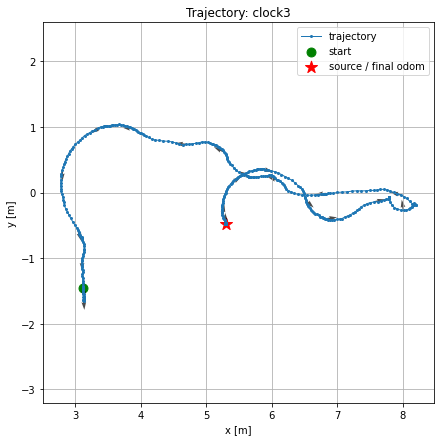

In [65]:
fig, ax = plt.subplots(figsize=(7, 7))
if len(positions):
    ax.plot(positions[:, 0], positions[:, 1], '-o', markersize=2, linewidth=1.0, label='trajectory')
    ax.scatter(positions[0, 0], positions[0, 1], c='green', s=80, label='start')
    ax.scatter(source[0], source[1], c='red', marker='*', s=160, label='source / final odom')
    step = max(len(positions) // 20, 1)
    ax.quiver(
        positions[::step, 0], positions[::step, 1],
        np.cos(yaws[::step]), np.sin(yaws[::step]),
        angles='xy', scale_units='xy', scale=6.0, width=0.004, alpha=0.7,
    )
ax.set_title(f'Trajectory: {seq_dir.name}')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.axis('equal')
ax.legend()
plt.show()

## Interactive Sample Viewer

In [66]:
def show_sample(index):
    sample = dataset[index]
    sample_id = sample['sample_id']
    audio = sample['audio_wave']
    sample_rate = int(sample['sample_rate'])
    image = tensor_image_to_numpy(sample['image'])
    depth = tensor_image_to_numpy(sample['depth']).squeeze()
    doa_map = sample['doa_map'].detach().cpu().numpy()
    distance_map = sample['distance_map'].detach().cpu().numpy()
    azimuth_rad = float(sample['azimuth_rad'])
    distance_m = float(sample['distance_m'])

    odom_path = seq_dir / 'odom' / f'{sample_id}.npy'
    odom = load_odom_file(odom_path) if odom_path.exists() else None
    pos = odom['position'] if odom is not None else None
    yaw = quat_xyzw_to_yaw(odom['quat_xyzw']) if odom is not None else 0.0

    fig = plt.figure(figsize=(18, 11))
    gs = fig.add_gridspec(3, 4)

    ax_traj = fig.add_subplot(gs[:, 0])
    if len(positions):
        ax_traj.plot(positions[:, 0], positions[:, 1], '-', color='0.65', linewidth=1.0)
        ax_traj.scatter(source[0], source[1], c='red', marker='*', s=180, label='source')
        if pos is not None:
            ax_traj.scatter(pos[0], pos[1], c='blue', s=70, label='current')
            ax_traj.arrow(pos[0], pos[1], 0.35 * np.cos(yaw), 0.35 * np.sin(yaw), head_width=0.08, color='blue')
            ax_traj.plot([pos[0], source[0]], [pos[1], source[1]], '--', color='red', linewidth=1.0, label='to source')
    ax_traj.set_title('Trajectory / target')
    ax_traj.set_xlabel('x [m]')
    ax_traj.set_ylabel('y [m]')
    ax_traj.axis('equal')
    ax_traj.legend(loc='best')

    ax_img = fig.add_subplot(gs[0, 1])
    ax_img.imshow(np.clip(image, 0.0, 1.0))
    ax_img.set_title('Image')
    ax_img.axis('off')

    ax_depth = fig.add_subplot(gs[0, 2])
    im_depth = ax_depth.imshow(depth, cmap='viridis')
    ax_depth.set_title('Depth [m]')
    ax_depth.axis('off')
    fig.colorbar(im_depth, ax=ax_depth, fraction=0.046)

    ax_polar = fig.add_subplot(gs[0, 3], projection='polar')
    ax_polar.plot([azimuth_rad, azimuth_rad], [0, max(distance_m, 1e-3)], color='red', linewidth=2)
    ax_polar.scatter([azimuth_rad], [distance_m], c='red', s=60)
    ax_polar.set_title(f'DOA az={np.degrees(azimuth_rad):.1f} deg, r={distance_m:.2f} m')
    ax_polar.set_theta_zero_location('E')
    ax_polar.set_theta_direction(1)

    ax_wave = fig.add_subplot(gs[1, 1:3])
    plot_audio_wave(ax_wave, audio, sample_rate)

    ax_spec = fig.add_subplot(gs[1, 3])
    plot_audio_spectrogram(ax_spec, audio, sample_rate)

    ax_doa = fig.add_subplot(gs[2, 1:3])
    angle_axis = np.linspace(-np.pi, np.pi, len(doa_map), endpoint=False)
    doa_for_plot = np.roll(doa_map, len(doa_map) // 2)
    ax_doa.plot(angle_axis, doa_for_plot)
    ax_doa.axvline(azimuth_rad, color='red', linestyle='--')
    ax_doa.set_title('DOA Gaussian')
    ax_doa.set_xlabel('azimuth [rad]')

    ax_dist = fig.add_subplot(gs[2, 3])
    r_axis = np.linspace(DISTANCE_MIN, DISTANCE_MAX, len(distance_map))
    ax_dist.plot(r_axis, distance_map)
    ax_dist.axvline(distance_m, color='red', linestyle='--')
    ax_dist.set_title('Distance Gaussian')
    ax_dist.set_xlabel('distance [m]')

    fig.suptitle(f'{seq_dir.name} / sample {sample_id} / idx {index}', fontsize=14)
    plt.tight_layout()
    plt.show()


slider = widgets.IntSlider(value=0, min=0, max=len(dataset) - 1, step=1, description='sample')
widgets.interact(show_sample, index=slider)

interactive(children=(IntSlider(value=0, description='sample', max=416), Output()), _dom_classes=('widget-inte…

<function __main__.show_sample(index)>